In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import time
import os
from joblib import dump, load
from imblearn.over_sampling import SMOTE
from sklearn import preprocessing
from collections import Counter
from pprint import pprint
import random
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,ConfusionMatrixDisplay,
    precision_score,recall_score,f1_score,
    roc_auc_score,roc_curve,RocCurveDisplay,
    confusion_matrix,classification_report,
    precision_recall_curve,average_precision_score
    )

import shap
from sklearn.svm import SVC

dados = pd.read_csv ("../Databases/PDACCTRL_samplesXfeatures_RAW.csv", sep=',')
dados

,Sample_ID,Grupo,MIMAT0000062_st,MIMAT0000063_st,MIMAT0000064_st,MIMAT0000065_st,MIMAT0000066_st,MIMAT0000067_st,MIMAT0000068_st,MIMAT0000069_st,...,MIMAT0031119_st,MIMAT0031120_st,MIMAT0031175_st,MIMAT0031176_st,MIMAT0031177_st,MIMAT0031178_st,MIMAT0031179_st,MIMAT0031180_st,MIMAT0031181_st,y
0,GSM2278612,PDAC,1.129491,5.508052,2.923399,1.751963,0.693354,0.750790,0.685247,5.234038,...,0.913821,0.660219,0.484359,0.954552,1.271430,1.405966,0.597030,0.935637,0.930258,1
1,GSM2278613,PDAC,1.727870,7.021726,4.075586,1.692451,0.748297,0.819648,1.228891,3.863134,...,0.572489,0.288395,0.911395,0.865855,1.191414,1.248563,0.880128,0.443996,0.461034,1
2,GSM2278614,PDAC,1.275866,5.847073,4.037849,1.675842,0.792464,0.854456,0.427473,5.030710,...,0.567179,0.585677,0.968250,0.416603,0.906936,0.515170,0.373492,1.029657,0.783717,1
3,GSM2278615,PDAC,1.231164,5.372768,3.634441,1.629729,0.835388,0.508545,0.633179,4.395977,...,0.606826,0.616086,0.910045,0.485816,0.481710,0.658906,0.486607,1.092210,0.877583,1
4,GSM2278616,PDAC,1.598425,5.448495,3.763625,1.970805,0.652223,0.442908,0.477028,4.051217,...,0.798609,0.780584,0.655019,0.591214,1.120507,1.493095,0.723840,0.936191,0.714010,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,GSM2278758,Controle,1.072158,6.132864,4.303285,1.466693,1.066174,0.743631,0.542135,4.761716,...,0.565492,0.494150,0.605459,0.665845,1.061685,0.433729,0.351924,0.844252,0.267246,0
103,GSM2278759,Controle,1.688142,5.986205,3.848825,2.162682,0.984778,0.885241,0.934689,4.002943,...,0.829502,0.562959,1.029765,0.616121,0.528186,1.066021,0.886998,0.823196,0.621138,0
104,GSM2278760,Controle,1.507370,5.871728,3.430393,1.897419,0.627474,0.908978,0.458824,4.791717,...,1.177363,0.819254,0.368961,0.541980,1.179273,0.513666,0.789142,1.221342,0.959684,0
105,GSM2278761,Controle,0.588391,6.057384,4.142099,1.870668,1.081216,0.611892,0.771683,5.097688,...,0.604917,0.446808,0.563384,0.238049,0.932333,0.753658,0.141102,1.277319,0.443357,0


In [10]:
#normalizar
dados_num = dados.drop(columns=["Sample_ID", "Grupo", "y"])
dados_cat =dados[["Grupo"]]

#Instaciar o objeto normalizador
normalizador = preprocessing.MinMaxScaler()
#treinar o modelo normalizador
modelo_normalizador_num = normalizador.fit(dados_num)
#Salvando modelo normalizador para uso posterior
os.makedirs('models_Tree_SVM', exist_ok=True)
dump(modelo_normalizador_num, open("models_Tree_SVM/normalizador_TCC_Tree_SVM.model" , "wb" ))

#normalizar os atributos numericos
dados_num_normalizado = modelo_normalizador_num.transform(dados_num)
# Normalizar os dados Categoricos
dados_cat_normalizado = pd.get_dummies(dados_cat, dtype='int', dummy_na=True)
# Converter dados numéricos normalizados para DataFrame
dados_num_df = pd.DataFrame(dados_num_normalizado, columns=dados_num.columns)
# unir atributos num e cat que foram normalizados
dados_final = dados_num_df.join(dados_cat_normalizado)
dados_final

,MIMAT0000062_st,MIMAT0000063_st,MIMAT0000064_st,MIMAT0000065_st,MIMAT0000066_st,MIMAT0000067_st,MIMAT0000068_st,MIMAT0000069_st,MIMAT0000070_st,MIMAT0000071_st,...,MIMAT0031175_st,MIMAT0031176_st,MIMAT0031177_st,MIMAT0031178_st,MIMAT0031179_st,MIMAT0031180_st,MIMAT0031181_st,Grupo_Controle,Grupo_PDAC,Grupo_nan
0,0.364020,0.616390,0.295100,0.357728,0.346143,0.246612,0.281153,0.791741,0.567829,0.293147,...,0.318945,0.485705,0.572516,0.820679,0.450881,0.418451,0.829685,0,1,0
1,0.566594,0.930115,0.621546,0.339320,0.389451,0.274622,0.596963,0.371203,0.940650,0.244754,...,0.753015,0.430443,0.524971,0.710573,0.730846,0.132892,0.395607,0,1,0
2,0.413573,0.686656,0.610854,0.334182,0.424265,0.288782,0.131408,0.729368,0.610426,0.575846,...,0.810807,0.150539,0.355937,0.197553,0.229818,0.473060,0.694120,0,1,0
3,0.398440,0.588351,0.496557,0.319919,0.458100,0.148070,0.250906,0.534658,0.831239,0.250591,...,0.751642,0.193662,0.103271,0.298098,0.341681,0.509392,0.780955,0,1,0
4,0.522772,0.604046,0.533159,0.425419,0.313721,0.121369,0.160196,0.428900,1.000000,0.237128,...,0.492416,0.259330,0.482838,0.881627,0.576288,0.418772,0.629635,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,0.344610,0.745889,0.686059,0.269489,0.640015,0.243700,0.198017,0.646852,0.622801,0.311664,...,0.442040,0.305828,0.447887,0.140583,0.208489,0.365372,0.216334,1,0,0
103,0.553144,0.715492,0.557298,0.484770,0.575855,0.301305,0.426057,0.414091,0.457515,0.127880,...,0.873334,0.274848,0.130887,0.582882,0.737640,0.353141,0.543719,1,0,0
104,0.491946,0.691766,0.438745,0.402720,0.294213,0.310961,0.149621,0.656055,0.669959,0.330950,...,0.201646,0.228655,0.517757,0.196500,0.640867,0.584396,0.856907,1,0,0
105,0.180837,0.730245,0.640391,0.394445,0.651872,0.190110,0.331365,0.749914,0.581655,0.119255,...,0.399272,0.039293,0.371028,0.364379,0.000000,0.616909,0.379254,1,0,0


In [11]:
# remover a classe 'Grupo_nan' por ser insignificante
#dados_filtered = dados[~dados['Management'].isin(['missing', 'simultaneous appendectomy'])].copy()
dados_filtered = dados_final.drop(columns=['Grupo_nan'])

# Segmentar os dados em atributos e classes
dados_classes = dados_filtered[['Grupo_Controle', 'Grupo_PDAC']]
dados_atributos = dados_filtered.drop(columns=['Grupo_Controle', 'Grupo_PDAC'])

# Preprocessamento
# Tratar colunas categóricas
dados_cat = dados_atributos.select_dtypes(include=['object']).columns
dados_cat_normalizado = pd.get_dummies(dados_cat, dtype='int')

# Tratar colunas numéricas
dados_num = dados_atributos.select_dtypes(include=['number']).columns

# Preencher NaNs numéricos com a média da coluna
dados_num_preenchido = dados_atributos[dados_num].fillna(dados_atributos[dados_num].mean())

# Juntar numéricos preenchidos e categóricos dummificados
dados_processados = pd.concat([dados_num_preenchido, dados_cat_normalizado], axis=1)

# Criar uma coluna de classe unificada (1 = PDAC, 0 = Controle)
# Isso transforma o DataFrame de 2 colunas em uma única Series binária
dados_classes_bin = np.where(dados_classes['Grupo_PDAC'] == 1, 1, 0)

# Construir o objeto SMOTE e executar o fit_resample
resampler = SMOTE(random_state=42)
dados_atributos_b, dados_classes_b = resampler.fit_resample(dados_processados, dados_classes_bin)

# Verificar a frequência das classes balanceadas
print('#### FREQUÊNCIA DAS CLASSES APÓS O BALANCEAMENTO ####')
print(Counter(dados_classes_b))

#### FREQUÊNCIA DAS CLASSES APÓS O BALANCEAMENTO ####
Counter({np.int64(1): 88, np.int64(0): 88})


c:\Users\cassi\miniconda3\envs\cancer_gpu\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [12]:
X = dados_atributos_b
y = dados_classes_b

# split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Treinando SVM...")

# modelo SVM (bom padrão para datasets biomédicos)
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,   # importante para ROC AUC depois
    random_state=42
)

# treino
svm_model.fit(X_train, y_train)

print("Treino concluído.")

# salvar modelo
os.makedirs('models_SVM', exist_ok=True)

nome_modelo = "modelo_SVM_TCC.joblib"
caminho_modelo = os.path.join(os.getcwd(), 'models_SVM', nome_modelo)
dump(svm_model, caminho_modelo)
print(f"Modelo SVM salvo em: {caminho_modelo}")

Treinando SVM...
Treino concluído.
Modelo SVM salvo em: c:\Users\cassi\OneDrive\Documentos\1-Programas\TCC\SVM\models_SVM\modelo_SVM_TCC.joblib


AVALIANDO: SVM
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
ROC AUC  : 1.0000


<Figure size 600x500 with 0 Axes>

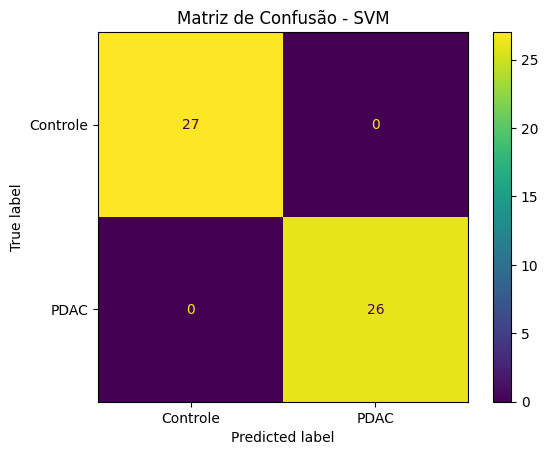

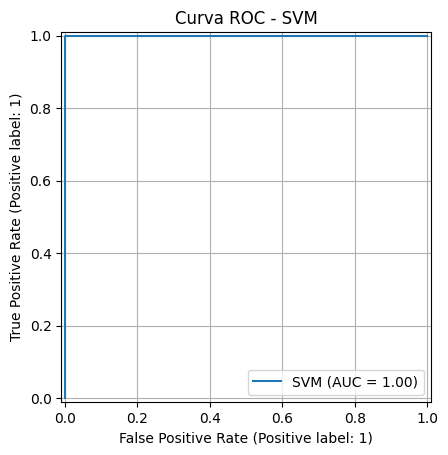



RANKING FINAL DOS MODELOS


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,SVM,1.0,1.0,1.0,1.0,1.0


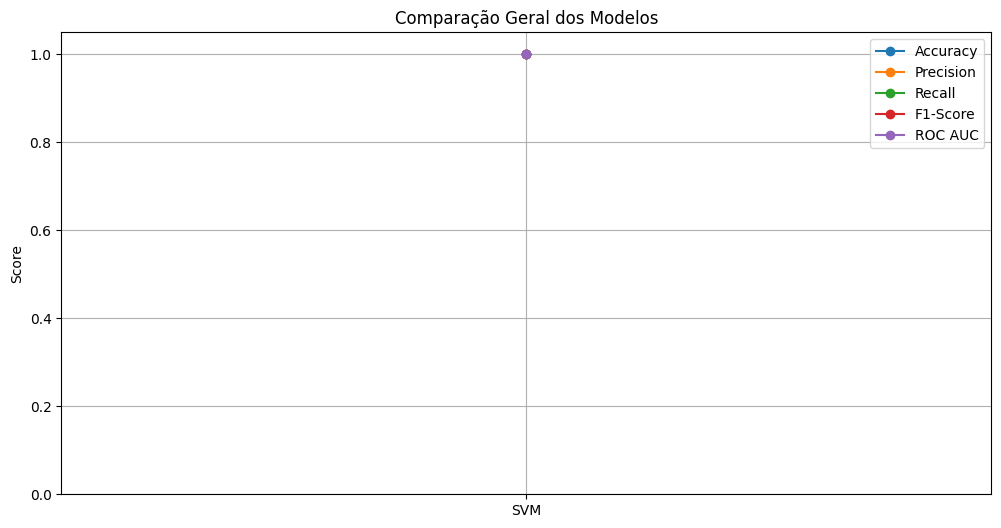

In [13]:
# CARREGAR MODELOS
modelos = {}

# SVM
caminho_svm = os.path.join(os.getcwd(), 'models_SVM', 'modelo_SVM_TCC.joblib')
if os.path.exists(caminho_svm):
    modelos["SVM"] = load(caminho_svm)

# Random Forest GPU
caminho_rf = os.path.join(
    os.getcwd(),
    'models_Tree_GPU',
    'modelo_RF_GPU_Grupo_PDAC.joblib'
)

if os.path.exists(caminho_rf):
    modelos["RandomForest_GPU"] = load(caminho_rf)

# XGBoost (caso exista futuramente)
caminho_xgb = os.path.join(
    os.getcwd(),
    'models_XGBoost_GPU',
    'modelo_XGBoost_TCC.joblib'
)

if os.path.exists(caminho_xgb):
    modelos["XGBoost_GPU"] = load(caminho_xgb)


# AVALIAÇÃO
resultados = []
for nome, modelo in modelos.items():
    print(f"AVALIANDO: {nome}")

    # previsões
    y_pred = modelo.predict(X_test)

    # alguns modelos retornam float
    y_pred = np.asarray(y_pred).astype(int)

    # probabilidades
    try:
        y_proba = modelo.predict_proba(X_test)[:, 1]
    except:
        y_proba = None

    # métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    if y_proba is not None:
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan

    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC AUC": roc_auc
    })

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

    if y_proba is not None:
        print(f"ROC AUC  : {roc_auc:.4f}")


    # MATRIZ DE CONFUSÃO
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Controle", "PDAC"]
    )
    disp.plot()
    plt.title(f"Matriz de Confusão - {nome}")
    plt.show()


    # CURVA ROC
    if y_proba is not None:
        RocCurveDisplay.from_predictions(
            y_test,
            y_proba,
            name=nome
        )

        plt.title(f"Curva ROC - {nome}")
        plt.grid(True)
        plt.show()


# TABELA COMPARATIVA
df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values(
    by="ROC AUC",
    ascending=False
)

print("\n")
print("RANKING FINAL DOS MODELOS")

display(df_resultados)


# GRÁFICO COMPARATIVO
metricas = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC AUC"
]

plt.figure(figsize=(12,6))

for metrica in metricas:
    plt.plot(
        df_resultados["Modelo"],
        df_resultados[metrica],
        marker="o",
        label=metrica
    )

plt.title("Comparação Geral dos Modelos")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()